In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Ielādē datu kopu tieši no UCI repozitorija
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)
print(f"Rindu skaits: {df.shape[0]}")
print(f"Kolonnu skaits: {df.shape[1]}")
df.head()

Rindu skaits: 12330
Kolonnu skaits: 18


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [2]:
# Datu tipi un trūkstošās vērtības
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [3]:
# Skaitlisko kolonnu statistika
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


In [4]:
# Trūkstošo vērtību skaits pa kolonnām
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [5]:
# Target mainīgā sadalījums
print(df['Revenue'].value_counts())
print(f"\nPirkumu veikušo sesiju īpatsvars:{df['Revenue'].mean():.1%}")

Revenue
False    10422
True      1908
Name: count, dtype: int64

Pirkumu veikušo sesiju īpatsvars:15.5%


**Cik rindu un kolonnu ir datu kopā?**

*Rindu skaits: 12330
Kolonnu skaits: 18*

**Kuras kolonnas ir skaitliskas, kuras — kategoriskas?**

*Skaitliskas: Administrative,
Administrative_Duration,
Informational,
Informational_Duration,
ProductRelated,
ProductRelated_Duration,
BounceRates,
ExitRates,
PageValues,
SpecialDay,
OperatingSystems,
Browser,
Region,
TrafficType.*

*Kategoriskas:
Month,
VisitorType,
Weekend,
Revenue*

**Cik trūkstošo vērtību ir katrā kolonnā?**

*Nav trūkstošo vērtību*

**Cik procentu sesiju beidzās ar pirkumu?**

*Pirkumu veikušo sesiju īpatsvars:15.5%*


In [6]:
# Trūkstošo vērtību vizualizācija
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print("✅ Nav trūkstošu vērtību — grafiks nav nepieciešams!")
else:
    plt.figure(figsize=(8, 4))
    missing.plot(kind='bar', color='coral')
    plt.title('Trūkstošās vērtības pa kolonnām')
    plt.ylabel('Skaits')
    plt.tight_layout()
    plt.show()

✅ Nav trūkstošu vērtību — grafiks nav nepieciešams!


In [7]:
from sklearn.preprocessing import StandardScaler
# Izvēlies kolonnas
numeric_cols = ['Administrative_Duration', 'Informational_Duration',
'ProductRelated_Duration', 'BounceRates', 'ExitRates',
'PageValues']
# Pirms normalizācijas — parādi statistiku
print("PIRMS normalizācijas:")
print(df[numeric_cols].describe().round(2))

PIRMS normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                     80.82                   34.47   
std                     176.78                  140.75   
min                       0.00                    0.00   
25%                       0.00                    0.00   
50%                       7.50                    0.00   
75%                      93.26                    0.00   
max                    3398.75                 2549.38   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                   1194.75         0.02       0.04        5.89  
std                    1913.67         0.05       0.05       18.57  
min                       0.00         0.00       0.00        0.00  
25%                     184.14         0.00       0.01        0.00  
50%                     598.94         0.

In [8]:
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("\nPĒC normalizācijas:")
print(df[numeric_cols].describe().round(2))


PĒC normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                      0.00                   -0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                     -0.00        -0.00       0.00        0.00  
std                       1.00         1.00       1.00        1.00  
min                      -0.62        -0.46      -0.89       -0.32  
25%                      -0.53        -0.46      -0.59       -0.32  
50%                      -0.31        -0.3

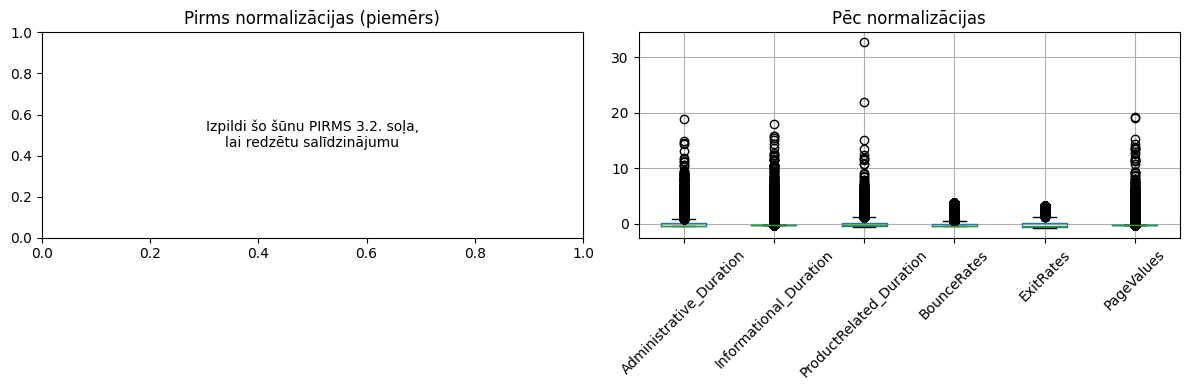

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Pirms (parādīsim uz vienas kolonnas piemēru)
axes[0].set_title('Pirms normalizācijas (piemērs)')
axes[0].text(0.5, 0.5, 'Izpildi šo šūnu PIRMS 3.2. soļa,\nlai redzētu salīdzinājumu',ha='center', va='center', transform=axes[0].transAxes)
# Pēc
df[numeric_cols].boxplot(ax=axes[1])
axes[1].set_title('Pēc normalizācijas')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Kuras kolonnas ir kategoriskas?
cat_cols = df.select_dtypes(include=['str', 'bool']).columns.tolist()
print("Kategoriskās kolonnas:", cat_cols)

for col in cat_cols:
    print(f"\n{col}: {df[col].unique()}")  # ✅ 4 atstarpes

Kategoriskās kolonnas: ['Month', 'VisitorType', 'Weekend', 'Revenue']

Month: <StringArray>
['Feb', 'Mar', 'May', 'Oct', 'June', 'Jul', 'Aug', 'Nov', 'Sep', 'Dec']
Length: 10, dtype: str

VisitorType: <StringArray>
['Returning_Visitor', 'New_Visitor', 'Other']
Length: 3, dtype: str

Weekend: [False  True]

Revenue: [False  True]


In [11]:
from sklearn.preprocessing import LabelEncoder

# Boolean kolonnas — pārvērš uz 0/1
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# One-Hot Encoding kategoriskām kolonnām
df = pd.get_dummies(df, columns=['Month', 'VisitorType'],drop_first=True)

print(f"Kolonnu skaits pēc kodēšanas: {df.shape[1]}")
df.head()

Kolonnu skaits pēc kodēšanas: 27


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor
0,0,-0.457191,0,-0.244931,1,-0.624348,3.667189,3.229316,-0.317178,0.0,...,True,False,False,False,False,False,False,False,False,True
1,0,-0.457191,0,-0.244931,2,-0.590903,-0.457683,1.171473,-0.317178,0.0,...,True,False,False,False,False,False,False,False,False,True
2,0,-0.457191,0,-0.244931,1,-0.624348,3.667189,3.229316,-0.317178,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,-0.457191,0,-0.244931,2,-0.622954,0.573535,1.994610,-0.317178,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,-0.457191,0,-0.244931,10,-0.296430,-0.045196,0.142551,-0.317178,0.0,...,True,False,False,False,False,False,False,False,False,True


In [12]:
# Pārliecinies, ka nav palikušas 'object' tipa kolonnas
remaining_objects = df.select_dtypes(include=['object','bool']).columns.tolist()
print(f"Atlikušās kategoriskās kolonnas: {remaining_objects}")
assert len(remaining_objects) == 0, "Vēl ir neapstrādātas kategoriskas kolonnas!"
print("✓ Visas kategoriskās kolonnas ir kodētas.")

Atlikušās kategoriskās kolonnas: ['Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor']


AssertionError: Vēl ir neapstrādātas kategoriskas kolonnas!

In [13]:
print(df.select_dtypes(include=['object', 'bool']).columns.tolist())
print(df.dtypes)

['Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor']
Administrative                     int64
Administrative_Duration          float64
Informational                      int64
Informational_Duration           float64
ProductRelated                     int64
ProductRelated_Duration          float64
BounceRates                      float64
ExitRates                        float64
PageValues                       float64
SpecialDay                       float64
OperatingSystems                   int64
Browser                            int64
Region                             int64
TrafficType                        int64
Weekend                            int64
Revenue                            int64
Month_Dec                           bool
Month_Feb                           bool
Month_Jul                           bool
Month_June                          bool
Month_M

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ielādē datus
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00468/online_shoppers_intention.csv"
df = pd.read_csv(url)
print(f"Ielādēts: {df.shape}")

# 2. Izlabo June → Jun
df['Month'] = df['Month'].str.replace('June', 'Jun')

# 3. Boolean → int
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)

# 4. One-Hot Encoding ar dtype=int
df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True, dtype=int)

print(f"Kolonnu skaits: {df.shape[1]}")
print(df.dtypes)

Ielādēts: (12330, 18)
Kolonnu skaits: 27
Administrative                     int64
Administrative_Duration          float64
Informational                      int64
Informational_Duration           float64
ProductRelated                     int64
ProductRelated_Duration          float64
BounceRates                      float64
ExitRates                        float64
PageValues                       float64
SpecialDay                       float64
OperatingSystems                   int64
Browser                            int64
Region                             int64
TrafficType                        int64
Weekend                            int64
Revenue                            int64
Month_Dec                          int64
Month_Feb                          int64
Month_Jul                          int64
Month_Jun                          int64
Month_Mar                          int64
Month_May                          int64
Month_Nov                          int64
Month_Oct       

In [15]:
# Pārliecinies, ka nav palikušas 'object' tipa kolonnas
remaining_objects = df.select_dtypes(include=['object','bool']).columns.tolist()
print(f"Atlikušās kategoriskās kolonnas: {remaining_objects}")
assert len(remaining_objects) == 0, "Vēl ir neapstrādātas kategoriskas kolonnas!"
print("✓ Visas kategoriskās kolonnas ir kodētas.")

Atlikušās kategoriskās kolonnas: []
✓ Visas kategoriskās kolonnas ir kodētas.


In [16]:
print(df.columns.tolist())

['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Revenue', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_Jun', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor']


In [27]:
# Kopējais laiks vietnē
df['TotalDuration'] = (df['Administrative_Duration'] +
df['Informational_Duration'] +
df['ProductRelated_Duration'])

# Piemērs 2: Bounce-to-Exit attiecība
df['BounceExitRatio'] = df['BounceRates'] / (df['ExitRates'] + 0.001)

In [28]:
print(df[['TotalDuration', 'BounceExitRatio']].describe())

       TotalDuration  BounceExitRatio
count   12330.000000     12330.000000
mean     1310.037228         0.282621
std      2037.801702         0.340708
min         0.000000         0.000000
25%       222.000000         0.000000
50%       680.000000         0.163296
75%      1626.908333         0.492611
max     69921.647230         3.626220


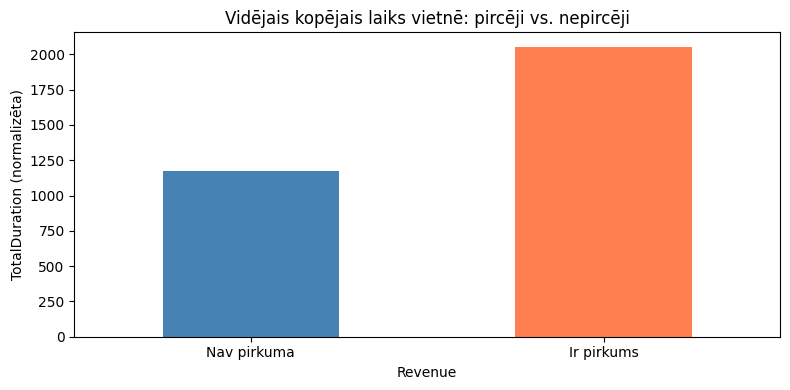

In [30]:
# Parādi, kā jaunā iezīme atšķiras starp pircējiem un nepircējiem
plt.figure(figsize=(8, 4))
df.groupby('Revenue')['TotalDuration'].mean().plot(kind='bar',
color=['steelblue', 'coral'])
plt.title('Vidējais kopējais laiks vietnē: pircēji vs. nepircēji')
plt.ylabel('TotalDuration (normalizēta)')
plt.xticks([0, 1], ['Nav pirkuma', 'Ir pirkums'], rotation=0)
plt.tight_layout()
plt.show()

In [31]:
# Saglabā tīro dataset nākamajai nedēļai
df.to_csv('shoppers_clean.csv', index=False)
print(f"Saglabāts: {df.shape[0]} rindas, {df.shape[1]} kolonnas")
print("✓ Tīrā datu kopa ir saglabāta failā 'shoppers_clean.csv'")

Saglabāts: 12330 rindas, 30 kolonnas
✓ Tīrā datu kopa ir saglabāta failā 'shoppers_clean.csv'


**1.Kādas datu kvalitātes problēmas tika atklātas?**

- Nekonsekventa mēneša nosaukuma rakstība — June vietā vajadzēja Jun kā pārējiem mēnešiem
- Neskaidra kategorija — VisitorType saturēja Other vērtību, kuras nozīme nav skaidra
- Trūkstoši mēneši — Month kolonnā bija tikai 10 no 12 mēnešiem (trūka janvāris un aprīlis)
- Potenciālie outlieri — TotalDuration max ~19 stundas, BounceExitRatio vērtības virs 1
- Kategoriskās kolonnas kā bool — pd.get_dummies() pēc noklusējuma izveidoja bool tipa kolonnas, nevis int

**2.Kādas darbības tika veiktas, lai tās atrisinātu?**

- June → Jun aizstāšana ar str.replace()
- Weekend un Revenue pārvēršana no bool uz int
- Month un VisitorType kodēšana ar pd.get_dummies(drop_first=True, dtype=int)

**3.Kā mainījās datu kopas struktūra?**

Kolonnu skaits:
- pirms 18
- pec 29
  
Jaunās kolonnas:
- Pirms 0
- Pēc Month_* (9), VisitorType_* (2), TotalDuration, BounceExitRatio
  
Kategoriskās kolonnas:
- Pirms 4
- Pēc 0